# **Ievads attēlu apstrādē**

## **Praktiskais darbs Nr. 2**

---

**Students:** Edgars Polis

**Studenta apliecības Nr.:** 241RDB296

**Saite uz programmēšanas kodu:** https://github.com/Edgars-P/RTU_IAA_MD/blob/main/LD2/IAA_LD2.ipynb

---

**Variants 6**

- Logaritmiskā korekcija
- Histogrammas izlīdzināšana


## **Programmas kods ar izvadi**

_Darbā jābūt iekļautam palaistam Python kodam, t. i., kodam jābūt izpildītam tā, lai dokumentā būtu redzamas visas vizualizācijas, attēli, grafiki un cita programmas izvade. Nepalaists kods vai kods bez redzamiem rezultātiem netiks uzskatīts par korekti iesniegtu. Kodam jābūt bez komentāriem._


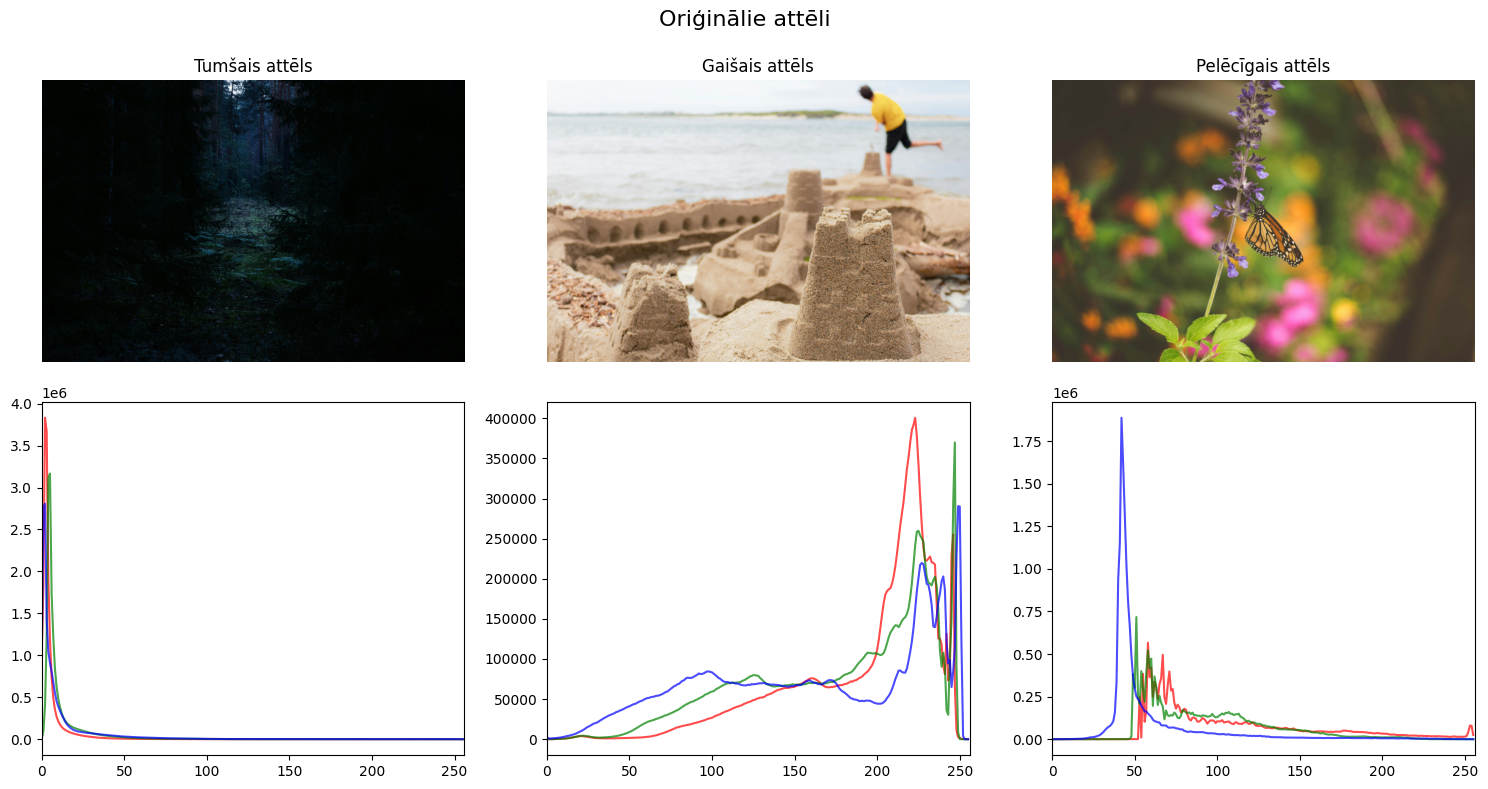

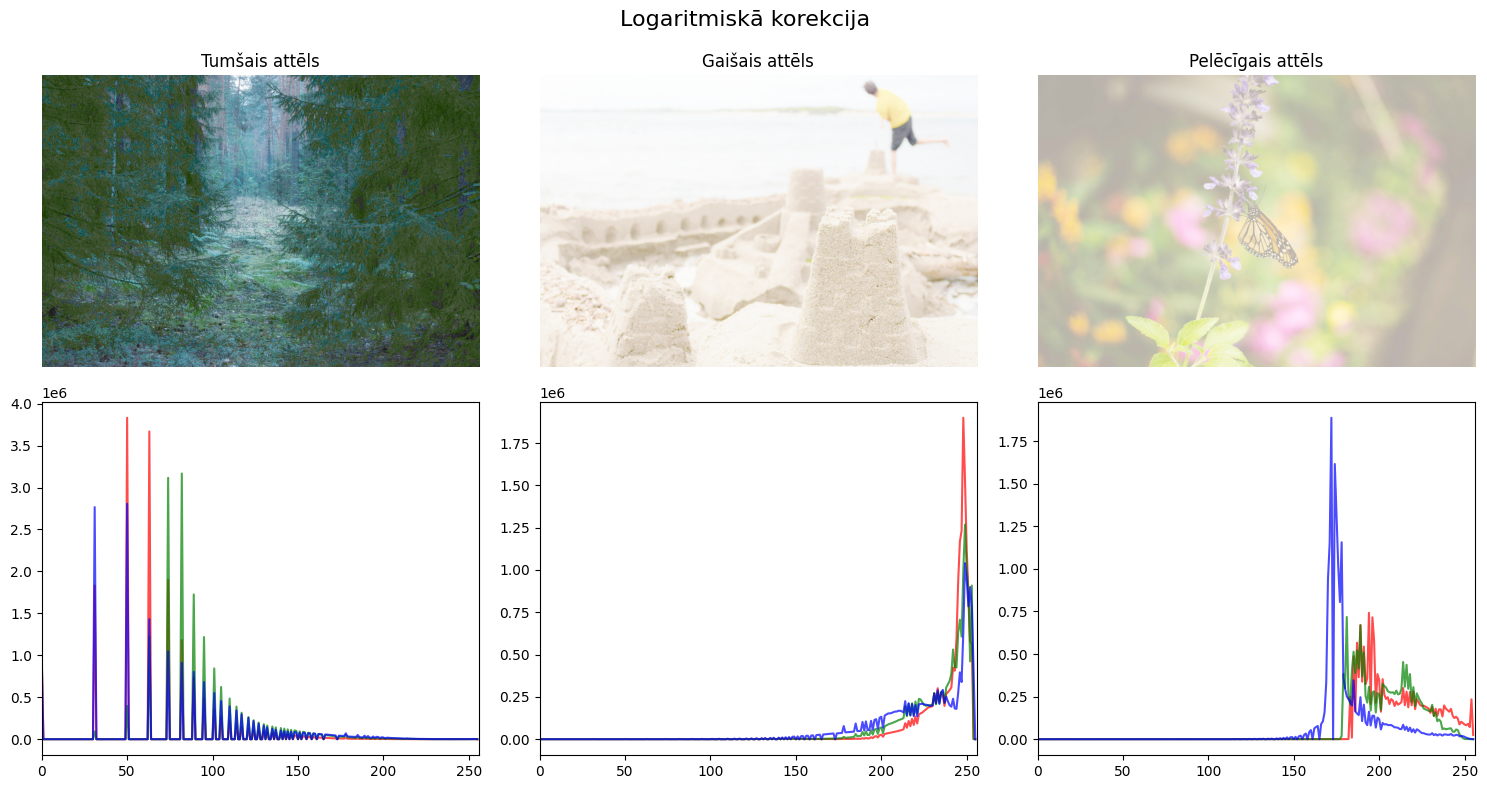

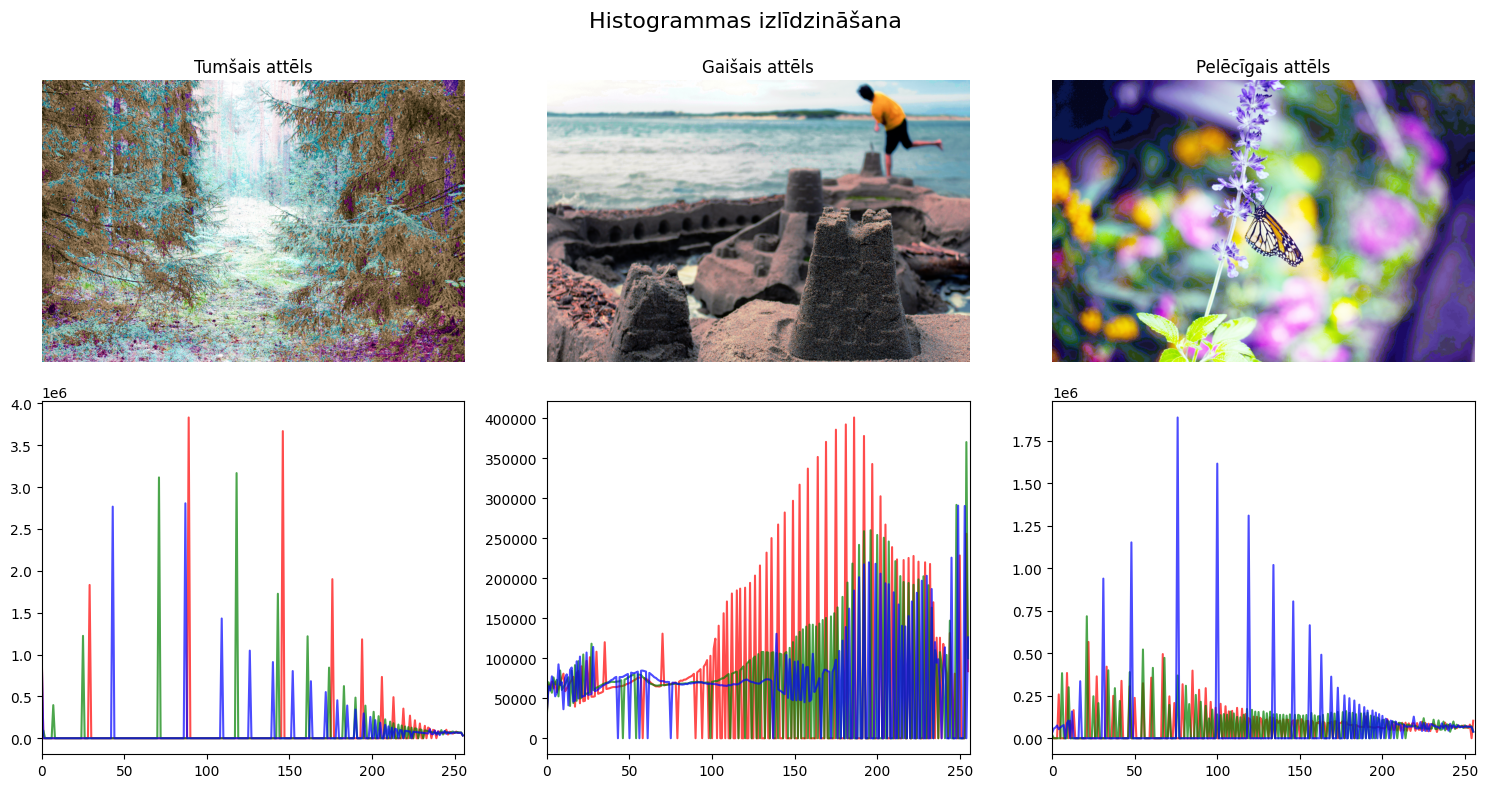

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

partumsots = cv2.imread("./partumsots.jpg")
pargaismots = cv2.imread("./pargaismots.jpg")
pelecigs = cv2.imread("./pelecigs.jpg")

partumsots_rgb = cv2.cvtColor(partumsots, cv2.COLOR_BGR2RGB)
pargaismots_rgb = cv2.cvtColor(pargaismots, cv2.COLOR_BGR2RGB)
pelecigs_rgb = cv2.cvtColor(pelecigs, cv2.COLOR_BGR2RGB)

w = min(partumsots_rgb.shape[1], pargaismots_rgb.shape[1], pelecigs_rgb.shape[1])
h = min(partumsots_rgb.shape[0], pargaismots_rgb.shape[0], pelecigs_rgb.shape[0])

A = cv2.resize(partumsots_rgb, (w, h))
B = cv2.resize(pargaismots_rgb, (w, h))
C = cv2.resize(pelecigs_rgb, (w, h))

def display_approach(img1, img2, img3, title):
    fig, axs = plt.subplots(2, 3, figsize=(15, 8))
    images = [img1, img2, img3]
    labels = ["Tumšais attēls", "Gaišais attēls", "Pelēcīgais attēls"]
    
    for i in range(3):
        # Image row
        axs[0, i].imshow(images[i])
        axs[0, i].set_title(labels[i])
        axs[0, i].axis("off")
        
        # Histogram row
        for col_idx, col_name in enumerate(['red', 'green', 'blue']):
            hist, _ = np.histogram(images[i][:,:,col_idx], bins=256, range=[0, 256])
            axs[1, i].plot(hist, color=col_name, alpha=0.7)
        axs[1, i].set_xlim([0, 256])
        
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

def log_correction_uint8(image):
    # I_new = c * log(1 + I_old)
    img_float = image.astype(np.float32)
    c = 255.0 / np.log(1.0 + 255.0) 
    result = c * np.log(1.0 + img_float)
    return np.clip(result, 0, 255).astype(np.uint8)

def hist_equalization_uint8(image):
    result = np.zeros_like(image)
    for ch in range(3):
        channel = image[:, :, ch]
        
        hist, _ = np.histogram(channel, bins=256, range=[0, 256])
        cdf = np.cumsum(hist)
        
        cdf_min = cdf[cdf > 0].min()
        total_pixels = channel.size
        cdf_normalized = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255.0)
        cdf_normalized = np.clip(cdf_normalized, 0, 255).astype(np.uint8)
        
        result[:, :, ch] = cdf_normalized[channel]
        
    return result


display_approach(A, B, C, "Oriģinālie attēli")

A_log = log_correction_uint8(A)
B_log = log_correction_uint8(B)
C_log = log_correction_uint8(C)
display_approach(A_log, B_log, C_log, "Logaritmiskā korekcija")

A_eq = hist_equalization_uint8(A)
B_eq = hist_equalization_uint8(B)
C_eq = hist_equalization_uint8(C)
display_approach(A_eq, B_eq, C_eq, "Histogrammas izlīdzināšana")

# **Secinājumi**

**Kādas galvenās vizuālās atšķirības ir redzamas starp dažādām kontrasta korekcijas metodēm?**

Galvenās atšķirības starp dotajām metodēm ir redzamas izgaismotos attēlos. Logaritmiskā korekcija vienkārši "pārbīda" visas tumšās krāsas tuvāk gaišajām. Tas nozīmē, ka attēli, kuros jau ir daudz gaišo krāsu, paliek pārāk izgaismoti, kā tas ir redzams gaišajos un pelēcīgajos attēlos.  
Savukārt histogrammas izlīdzināšana katru krāsas kanālu "izstiepj" pa visu 0-255 diapazonu. Tas nozīmē, ka attēli parāda daudz vairāk detaļu, bet zaudē krāsu precīzumu.  
Abos gadījumos tumšais attēls, vismaz manām acīm, ir tikpat labi salasāms, bet logaritmiskā korekcija saglabā vairāk oriģinālo krāsu.

**Kura metode vislabāk uzlabo attēlu kvalitāti un saglabā detaļas?**

Salīdzinot logaritmisko korekciju un histogrammas izlīdzināšanu, histogrammas izlīdzināšana noteikti uzlabo kvalitāti visvairāk. Izgaismotos attēlos logaritmiskā korekcija zaudē detaļas, un pat tumšā attēla gadījumā histogrammas izlīdzināšana atklāj vairāk zaru tumsā nekā logaritmiskā korekcija.

**Kādas ir katras metodes priekšrocības un trūkumi?**

Logaritmiskā korekcija ir noderīga, ja ir tumši attēli un ir nepieciešams saglabāt krāsas. Gaišos attēlos un tumšo attēlu gaišajos apgabalos detaļas tiek zaudētas.  
Histogrammas izlīdzināšana ir noderīga, ja ir nepieciešams izgūt pēc iespējas vairāk detaļu no attēla tā, lai cilvēks var tās redzēt ar neapbruņotu aci. Taču tiek zaudēts krāsu precīzums.
